AI-generated code notice: The plotting code in this notebook was generated with assistance from the ChatGPT 5.6 Sol model to produce clearer and more intuitive visualisations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from pathlib import Path

### Task 1: AUC Performance Comparison Between Random Forest and XGBoost Across Policy Levels and Behavioural Outcomes

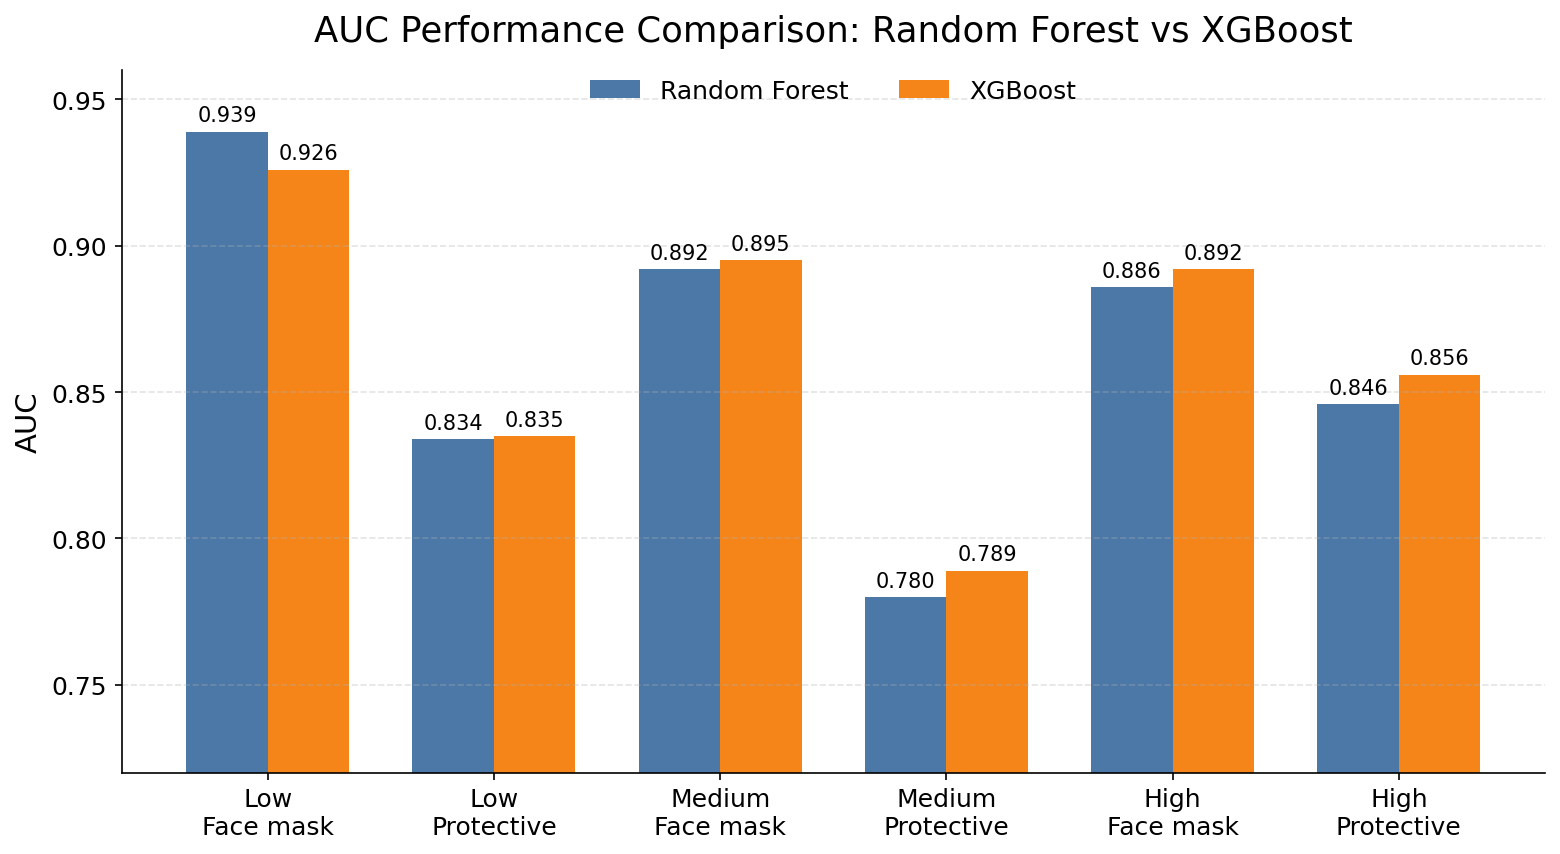

In [2]:
# AUC values from the Random Forest and XGBoost performance
auc_data = pd.DataFrame(
    [
        ("Low", "Face mask", 0.939, 0.926),
        ("Low", "Protective", 0.834, 0.835),
        ("Medium", "Face mask", 0.892, 0.895),
        ("Medium", "Protective", 0.780, 0.789),
        ("High", "Face mask", 0.886, 0.892),
        ("High", "Protective", 0.846, 0.856),
    ],
    columns=["Policy", "Outcome", "Random Forest", "XGBoost"],
)

labels = auc_data["Policy"] + "\n" + auc_data["Outcome"]
x = np.arange(len(labels))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=150)
rf_bars = ax.bar(
    x - bar_width / 2,
    auc_data["Random Forest"],
    width=bar_width,
    label="Random Forest",
    color="#4C78A8",
)
xgb_bars = ax.bar(
    x + bar_width / 2,
    auc_data["XGBoost"],
    width=bar_width,
    label="XGBoost",
    color="#F58518",
)

ax.set_title("AUC Performance Comparison: Random Forest vs XGBoost", fontsize=17, pad=14)
ax.set_ylabel("AUC", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0.72, 0.96)
ax.tick_params(axis="y", labelsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.02), fontsize=12)

for bars in (rf_bars, xgb_bars):
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)

fig.tight_layout()

fig.savefig("../Figure/auc_rf_xgboost_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 2: Policy-Level Top-10 Feature Importance Comparison Between Random Forest and XGBoost for Two Behavioural Outcomes

In [3]:
importance_dir = Path("../Importance")
figure_dir = Path("../Figure")
figure_dir.mkdir(parents=True, exist_ok=True)
top_n = 10

feature_labels = {
    "C_policy_mean": "Containment policy",
    "E_policy_mean": "Economic policy",
    "H_policy_mean": "Health-system policy",
    "week_number": "Survey wave",
    "i2_health": "Close contacts",
    "r1_1": "Perceived COVID-19 severity",
    "r1_2": "Perceived infection risk",
    "cantril_ladder": "Life satisfaction",
    "WCRex2_No confidence at all": "No health-service confidence",
    "i9_health_Yes": "Symptomatic isolation: Yes",
    "i9_health_Not sure": "Symptomatic isolation: Unsure",
    "i11_health_Very willing": "Very willing to self-isolate",
    "i11_health_Somewhat willing": "Somewhat willing to self-isolate",
    "i11_health_Very unwilling": "Very unwilling to self-isolate",
    "employment_status_Retired": "Retired",
    "employment_status_Not working": "Not working",
}

def format_feature_display_name(name):
    return feature_labels.get(name, name.replace("_", " " ).strip().capitalize())


In [4]:
def plot_policy_level_feature_importance(policy, policy_label, output_name):
    outcome_specs = [
        ("face_mask", "Face-mask behaviour"),
        ("protective", "Overall protective behaviour"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10.5), dpi=150)
    outcome_titles = []

    for row, (outcome, outcome_label) in enumerate(outcome_specs):
        ax_rf, ax_xgb = axes[row]
        rf = pd.read_csv(importance_dir / f"rf_{policy}_policy_{outcome}_importance.csv").nlargest(top_n, "median_importance")
        xgb = pd.read_csv(importance_dir / f"xgb_{policy}_policy_{outcome}_importance.csv").nlargest(top_n, "median_importance")

        rf_values = rf["median_importance"].to_numpy()
        xgb_values = xgb["median_importance"].to_numpy()
        rf_q1 = rf["q1"].to_numpy()
        rf_q3 = rf["q3"].to_numpy()
        xgb_q1 = xgb["q1"].to_numpy()
        xgb_q3 = xgb["q3"].to_numpy()
        y_rf = np.arange(len(rf))
        y_xgb = np.arange(len(xgb))

        ax_rf.barh(y_rf, rf_values, xerr=np.vstack([rf_values - rf_q1, rf_q3 - rf_values]), color="#4C78A8", alpha=0.9, capsize=3)
        ax_xgb.barh(y_xgb, xgb_values, xerr=np.vstack([xgb_values - xgb_q1, xgb_q3 - xgb_values]), color="#F58518", alpha=0.9, capsize=3)

        ax_rf.set_xlim(0, rf_q3.max() * 1.12)
        ax_xgb.set_xlim(xgb_q3.max() * 1.12, 0)
        rf_names = [format_feature_display_name(feature) for feature in rf["feature"]]
        xgb_names = [format_feature_display_name(feature) for feature in xgb["feature"]]
        ax_rf.set_yticks(y_rf, rf_names, fontsize=12)
        ax_xgb.set_yticks(y_xgb, xgb_names, fontsize=12)
        ax_xgb.yaxis.tick_right()
        ax_xgb.tick_params(axis="y", left=False, right=True, labelleft=False, labelright=True)
        ax_rf.invert_yaxis()
        ax_xgb.invert_yaxis()
        ax_rf.tick_params(axis="x", labelsize=11)
        ax_xgb.tick_params(axis="x", labelsize=11)
        ax_rf.set_xlabel("Median feature importance", fontsize=12.5)
        ax_xgb.set_xlabel("Median feature importance", fontsize=12.5)
        ax_rf.set_title("Random Forest", color="#4C78A8", fontsize=13.5, fontweight="bold", pad=10)
        ax_xgb.set_title("XGBoost", color="#F58518", fontsize=13.5, fontweight="bold", pad=10)
        outcome_titles.append(ax_rf.text(1.03, 1.14, outcome_label, transform=ax_rf.transAxes, ha="center", fontsize=16))

        for ax in (ax_rf, ax_xgb):
            ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
            ax.grid(axis="x", linestyle="--", alpha=0.3)
            ax.set_axisbelow(True)
            ax.spines[["top", "left", "right"]].set_visible(False)
            ax.axvline(0, color="#333333", linewidth=1)

    main_title = fig.suptitle(f"{policy_label} policy intensity", fontsize=18, y=0.995)
    fig.subplots_adjust(left=0.25, right=0.75, top=0.89, bottom=0.06, wspace=0.04, hspace=0.48)
    fig.canvas.draw()
    tight_bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    content_center = (tight_bbox.x0 + tight_bbox.x1) / (2 * fig.get_figwidth())
    main_title.set_x(content_center)
    for row, title in enumerate(outcome_titles):
        left_position = axes[row, 0].get_position()
        title.set_x((content_center - left_position.x0) / left_position.width)
    output_path = figure_dir / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0.12)
    plt.show()
    return None


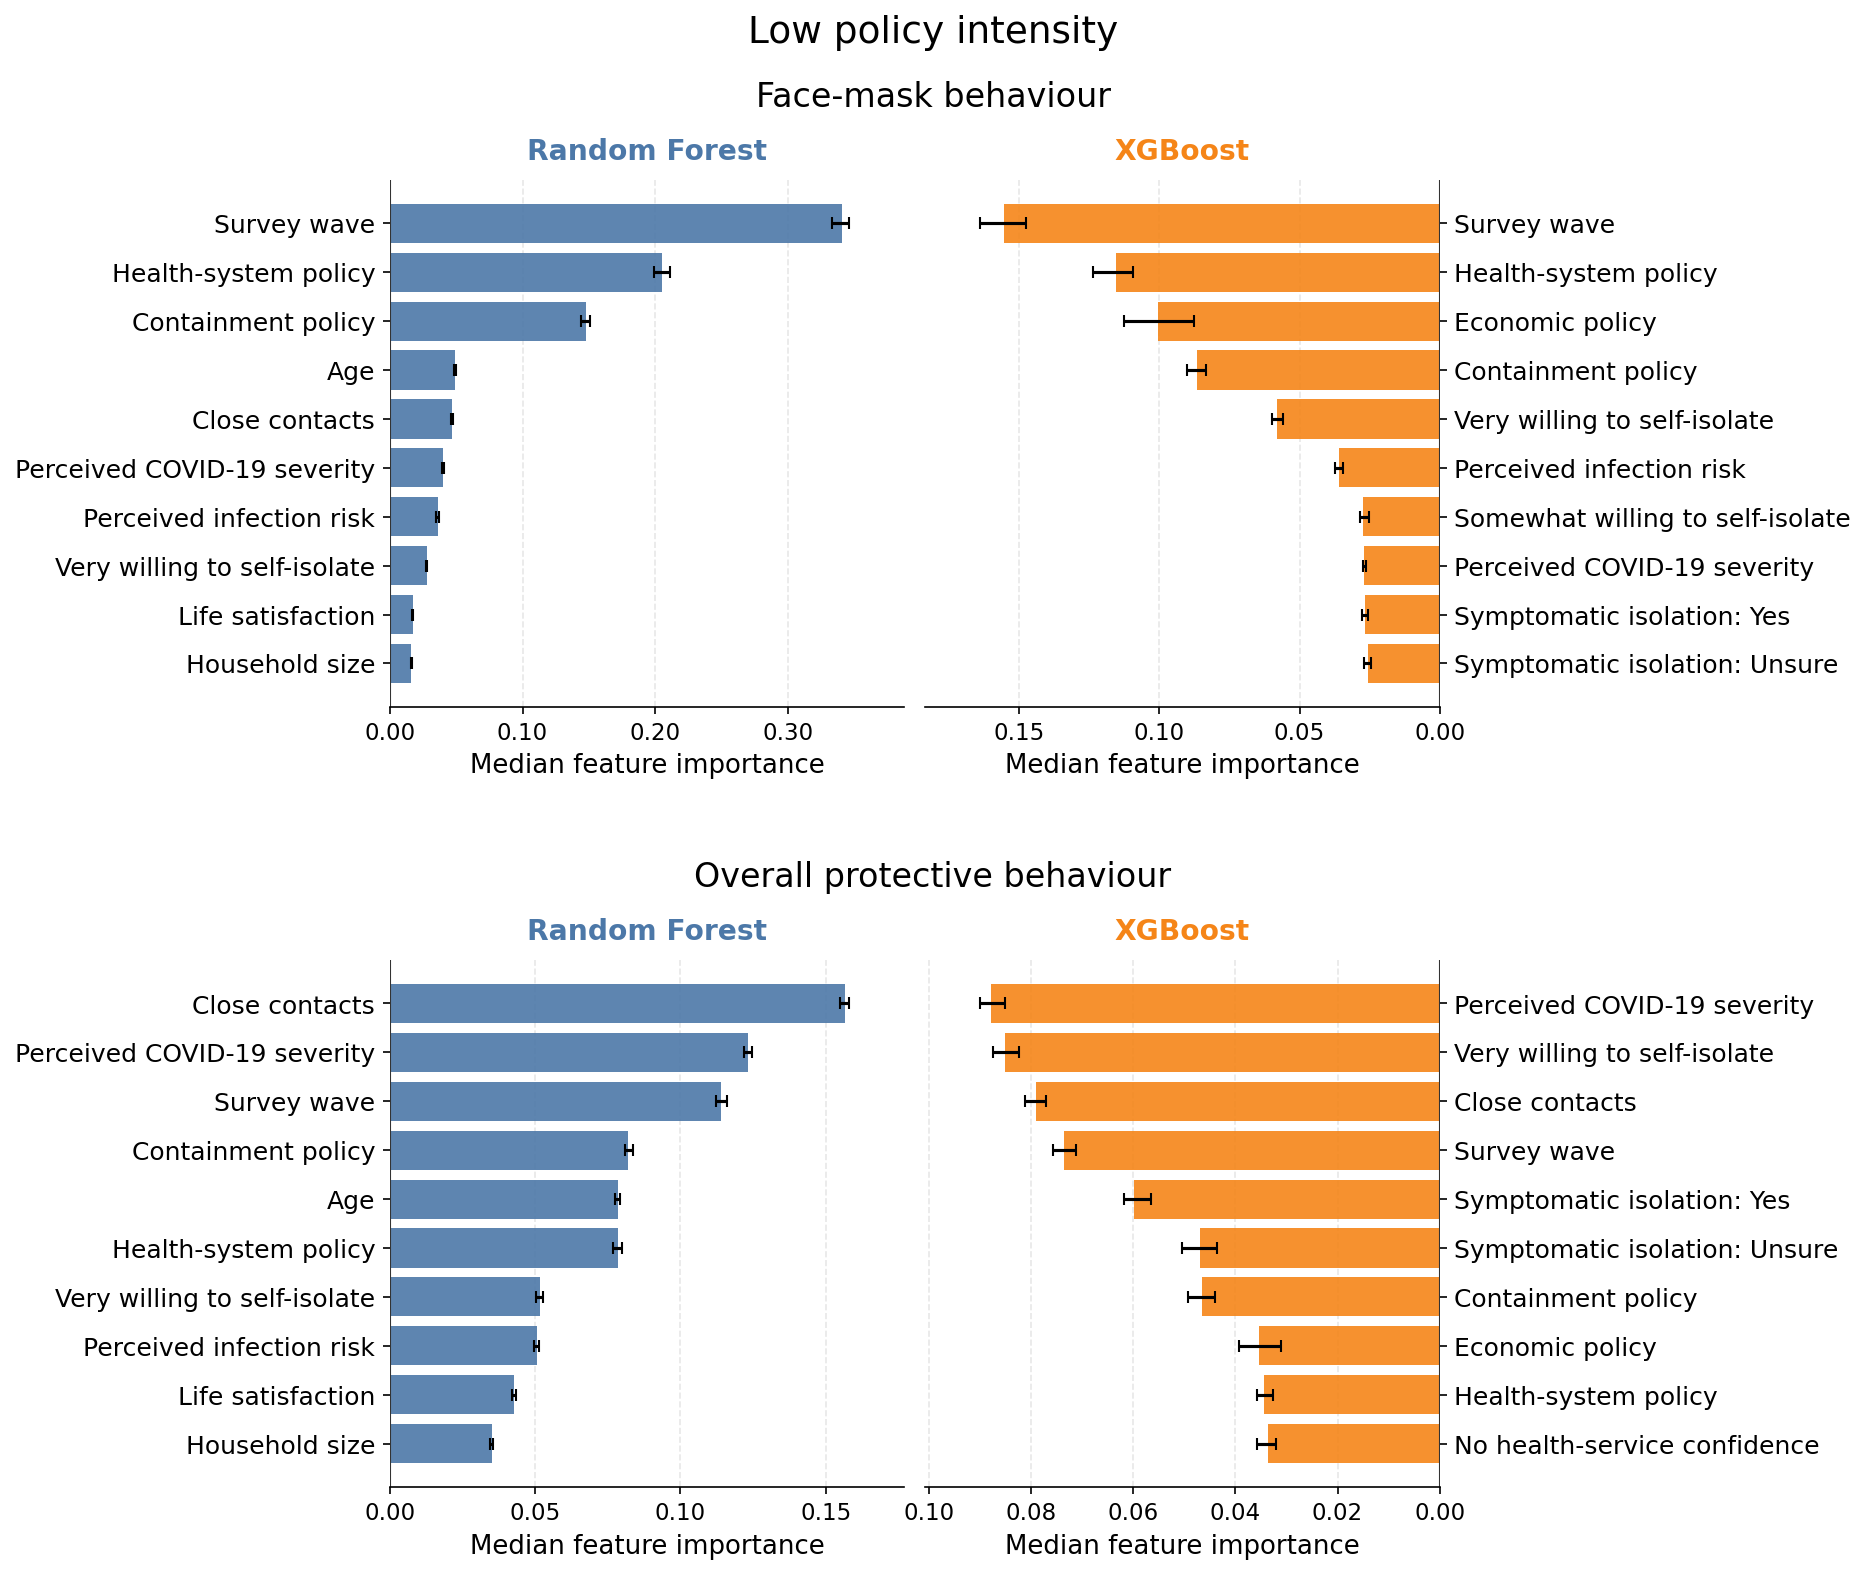

In [5]:
# Low policy intensity: model-specific Top 10 feature importance
plot_policy_level_feature_importance(
    policy="low",
    policy_label="Low",
    output_name="low_policy_feature_importance.png",
)

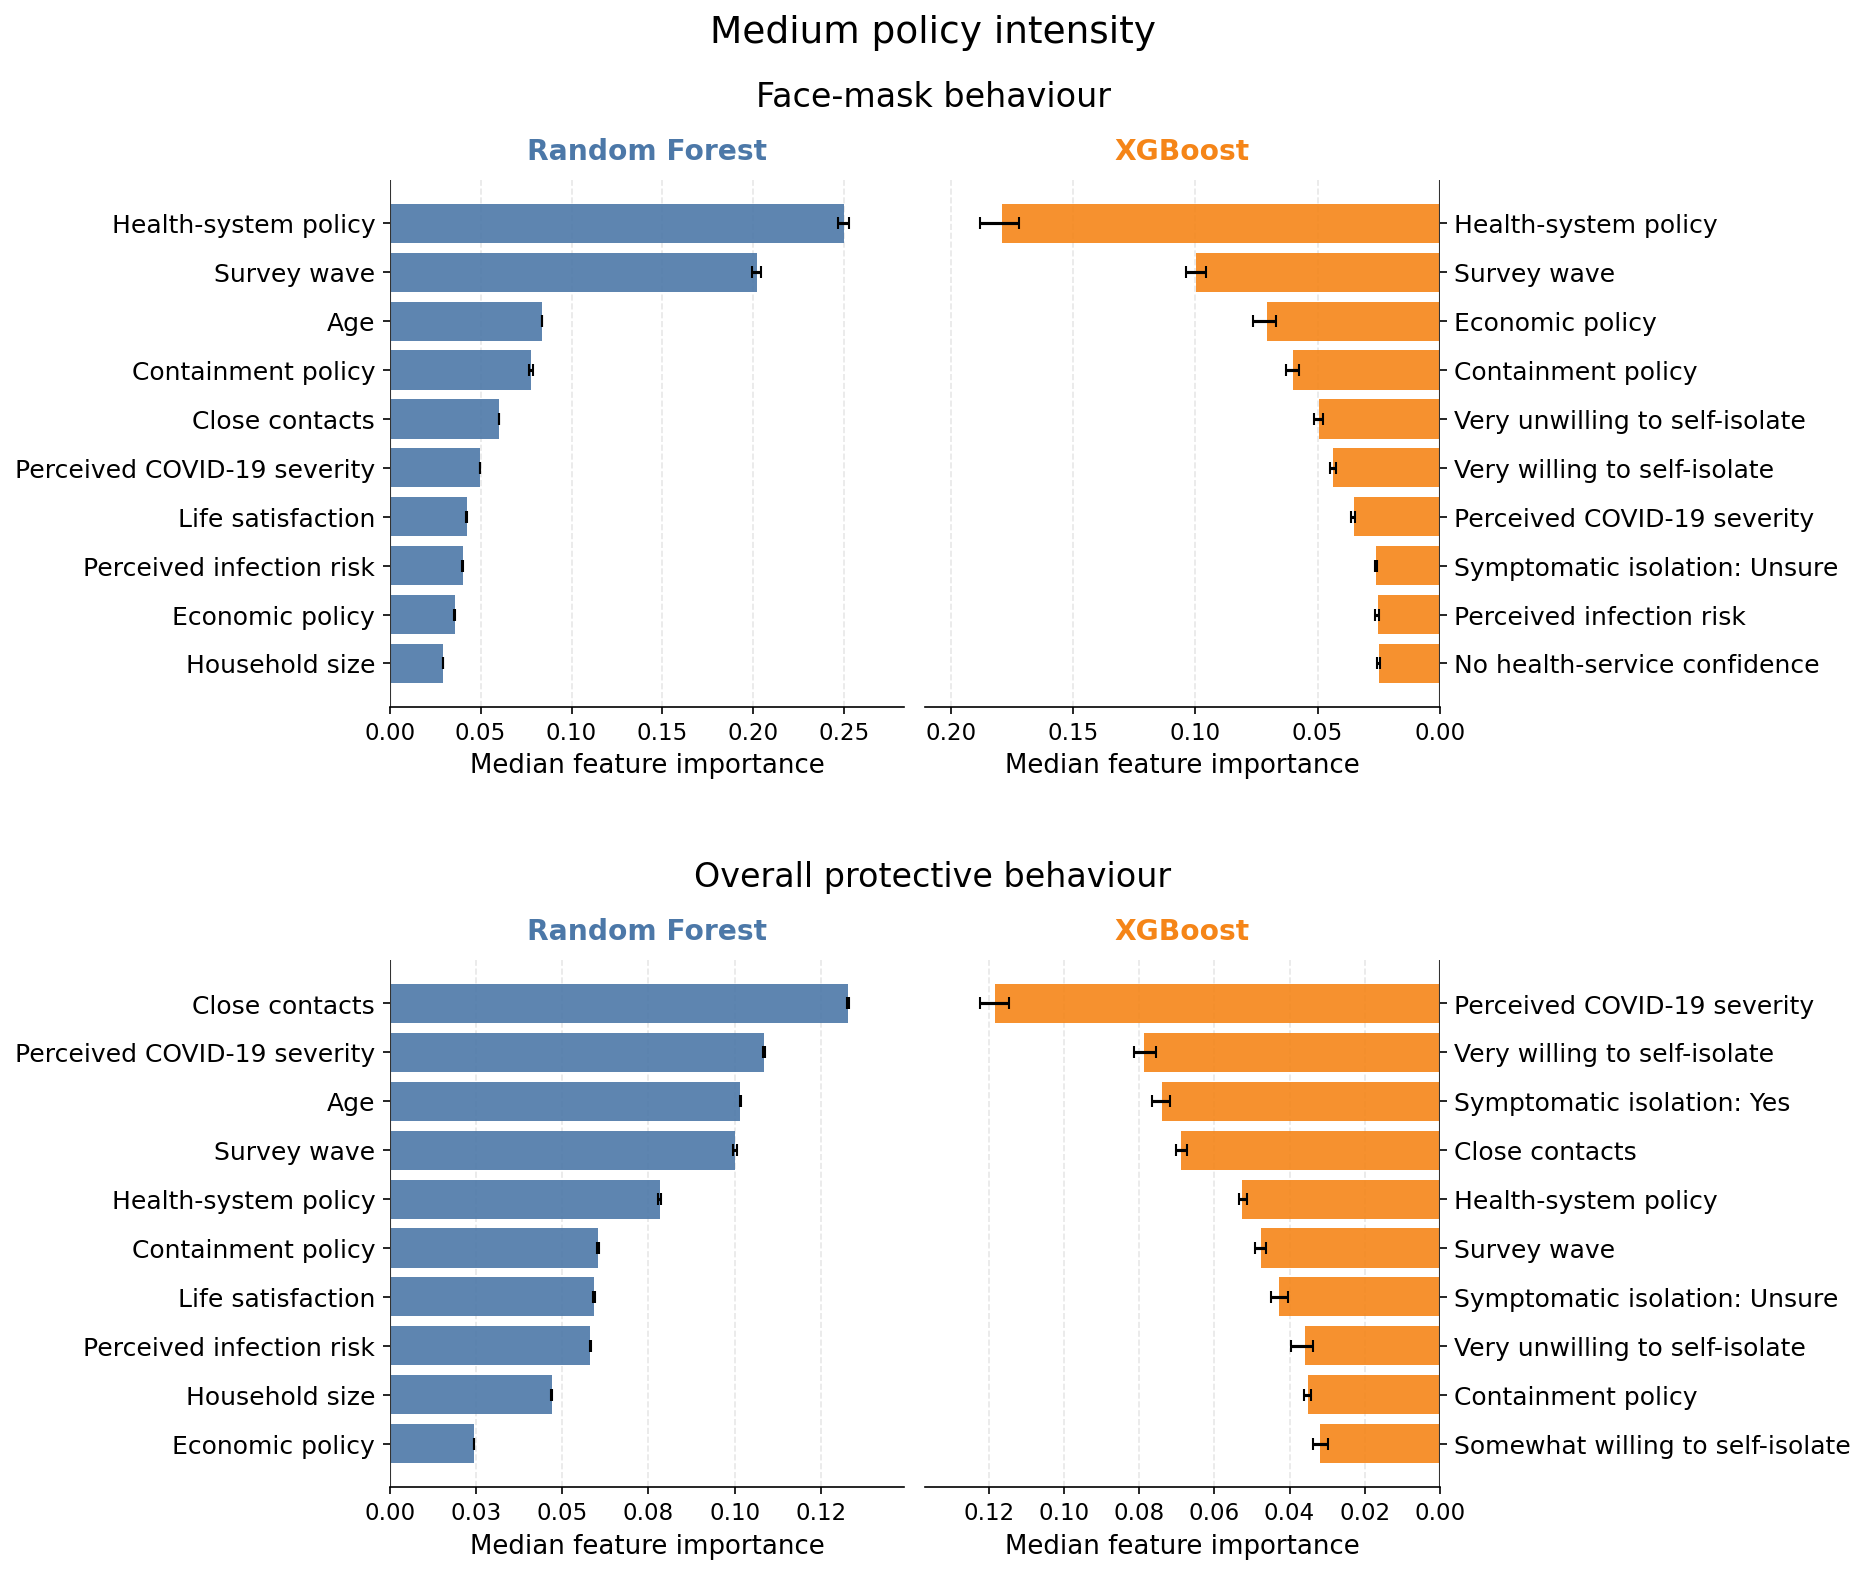

In [6]:
# Medium policy intensity: model-specific Top 10 feature importance
plot_policy_level_feature_importance(
    policy="medium",
    policy_label="Medium",
    output_name="medium_policy_feature_importance.png",
)

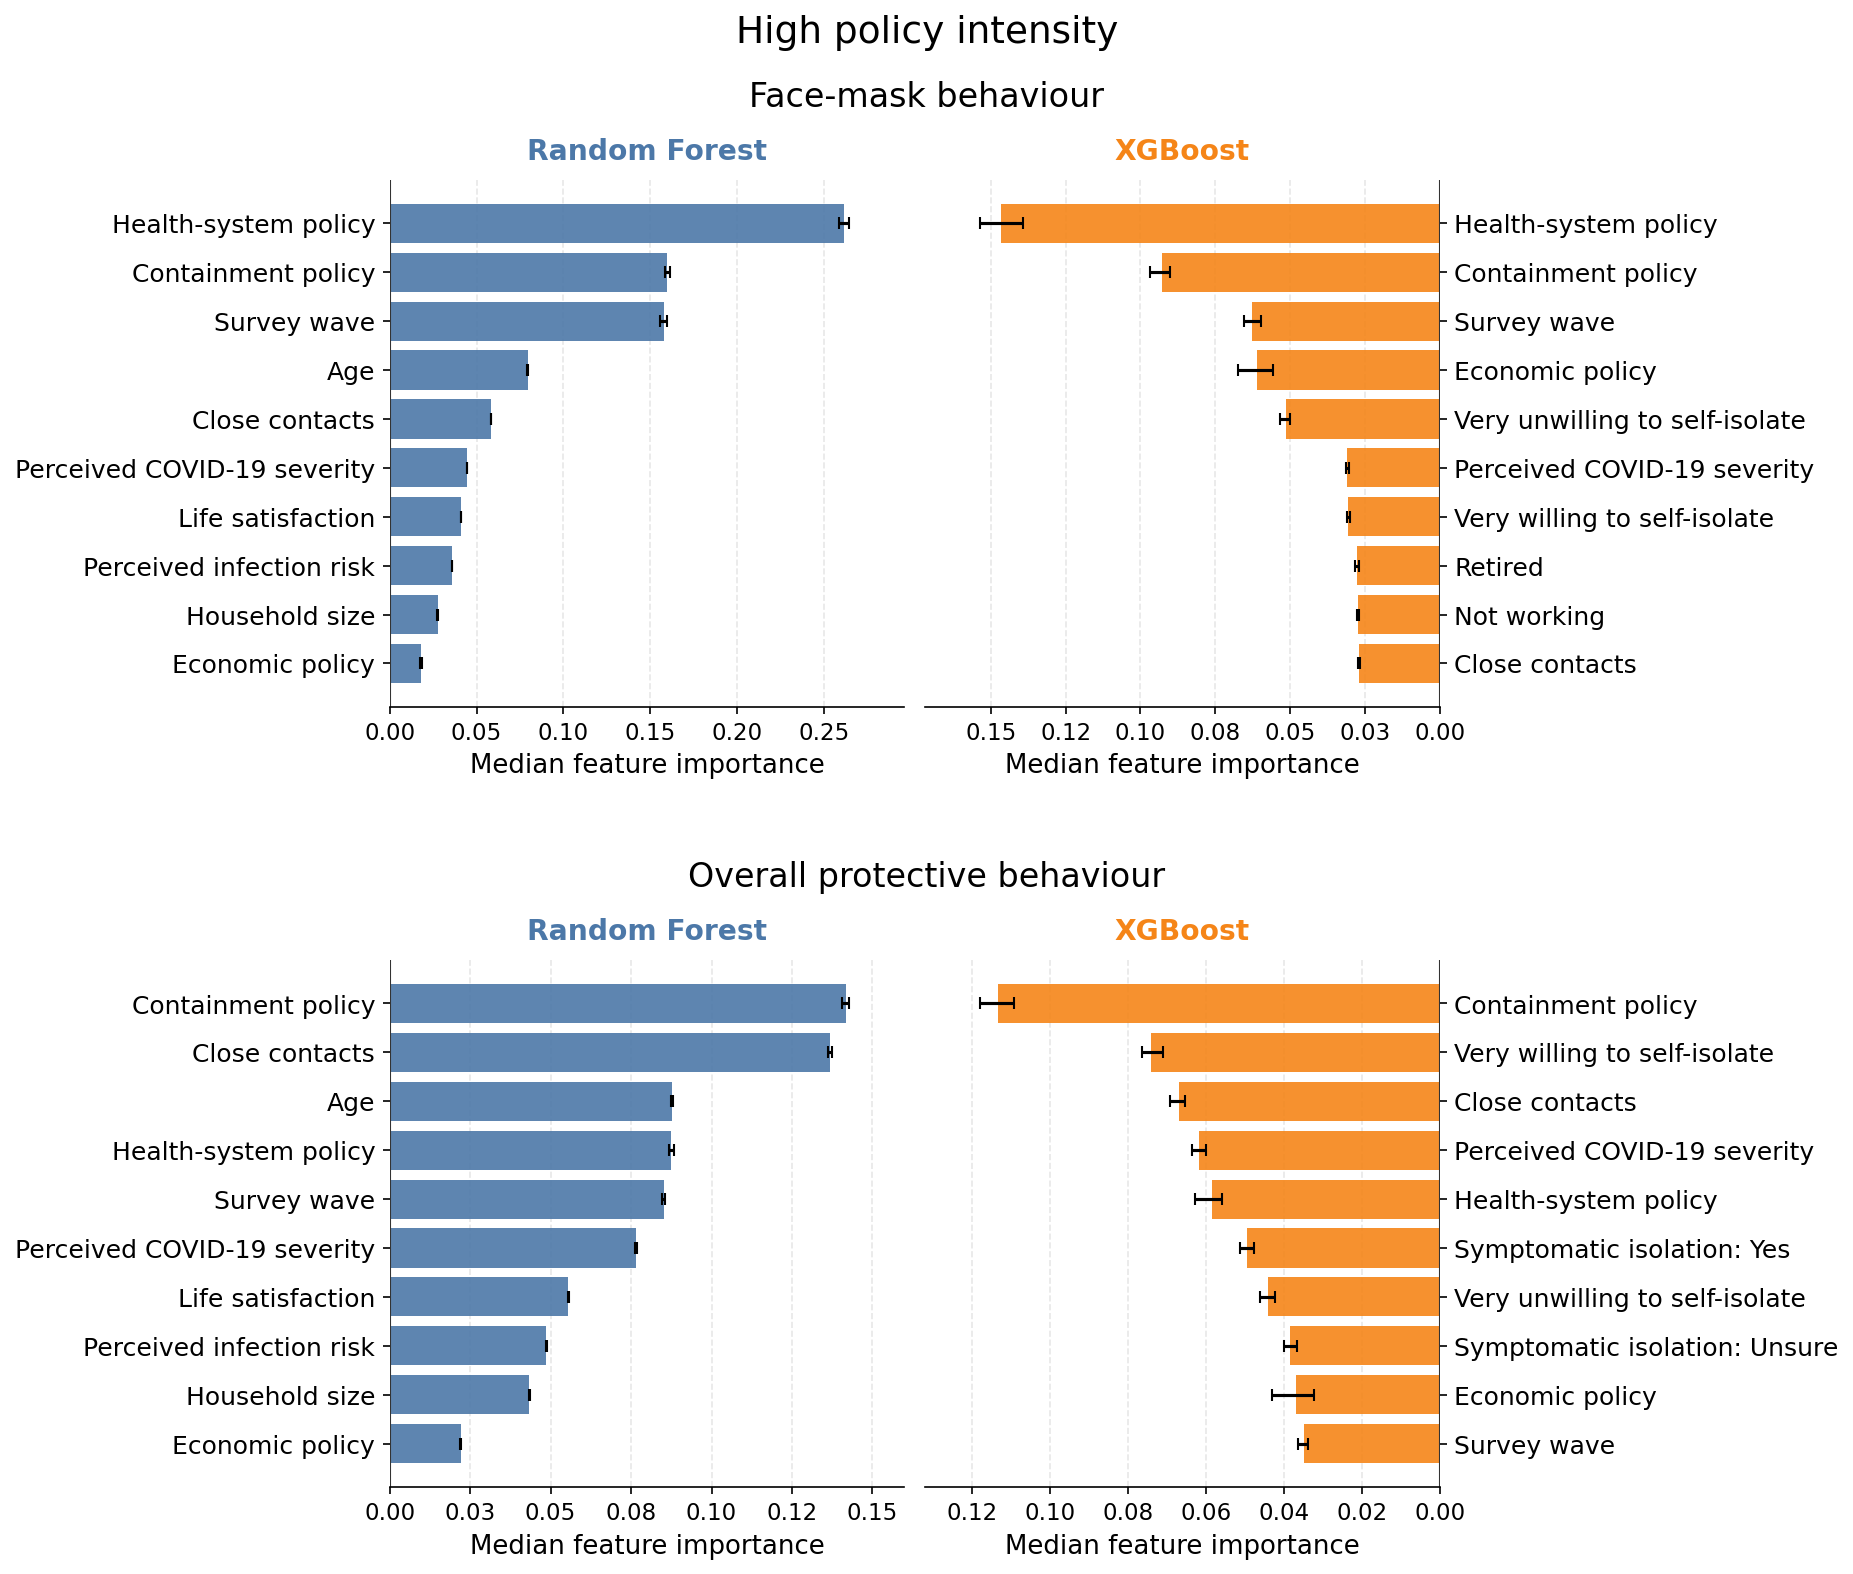

In [7]:
# High policy intensity: model-specific Top 10 feature importance
plot_policy_level_feature_importance(
    policy="high",
    policy_label="High",
    output_name="high_policy_feature_importance.png",
)